In [1]:
#Import pandas, matplotlib.pyplot, and seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
#Import the clean dataset 
df=pd.read_csv(r"../data/brfss_2021_clean.csv")

In [3]:
#Review the first few rows
df.head()

,_STATE,PERSDOC3,_RFHYPE6,MARITAL,EMPLOY1,_METSTAT,_URBSTAT,_RFHLTH,_PHYS14D,_HLTHPLN,...,_CURECI1_missing,_SMOKER3_missing,DRNKANY5_missing,GRENDA1__missing,FRNCHDA__missing,_FRUTSU1_missing,_VEGESU1_missing,_BMI5_missing,INCOME_GROUP,HIGHBP
0,1.0,1.0,1.0,1.0,7.0,1.0,1.0,2.0,3.0,1.0,...,0,0,0,0,0,0,0,0,Low,0
1,1.0,2.0,2.0,1.0,8.0,1.0,1.0,1.0,1.0,1.0,...,0,0,0,0,0,0,0,1,Missing,1
2,1.0,2.0,2.0,3.0,7.0,1.0,1.0,1.0,1.0,1.0,...,0,0,0,0,0,0,0,0,Low,1
3,1.0,1.0,2.0,1.0,7.0,1.0,1.0,1.0,1.0,1.0,...,0,0,0,0,0,0,0,0,Medium,1
4,1.0,1.0,1.0,1.0,8.0,2.0,1.0,2.0,3.0,1.0,...,0,0,0,0,0,0,0,0,Low,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436781 entries, 0 to 436780
Data columns (total 39 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   _STATE            436781 non-null  float64
 1   PERSDOC3          436781 non-null  float64
 2   _RFHYPE6          436781 non-null  float64
 3   MARITAL           436781 non-null  float64
 4   EMPLOY1           436781 non-null  float64
 5   _METSTAT          436781 non-null  float64
 6   _URBSTAT          436781 non-null  float64
 7   _RFHLTH           436781 non-null  float64
 8   _PHYS14D          436781 non-null  float64
 9   _HLTHPLN          436781 non-null  float64
 10  _TOTINDA          436781 non-null  float64
 11  _RACE             436781 non-null  float64
 12  _SEX              436781 non-null  float64
 13  _AGEG5YR          383410 non-null  float64
 14  _AGE80            436781 non-null  float64
 15  _BMI5             436781 non-null  float64
 16  _BMI5CAT          39

In [5]:
df.shape

(436781, 39)

In [6]:
#Target Variable Exploration - We will look at the distribution of the hypertension question 

#Target variable question - Adults who have been told they have high blood pressure by a doctor, nurse, or other health professional (1=No, 2=Yes)
print(df['_RFHYPE6'].value_counts(normalize=True))

_RFHYPE6
1.0    0.605905
2.0    0.394095
Name: proportion, dtype: float64


In [7]:
#Recode hypertension variable (_RFHYPE6) to a binary as this is easier to interpret (0=No, 1=Yes)

df['_RFHYPE6'] = df['_RFHYPE6'].replace({
    1: 0,  # No → 0
    2: 1   # Yes → 1
})

#Check
print(df['_RFHYPE6'].value_counts(normalize=True))

_RFHYPE6
0.0    0.605905
1.0    0.394095
Name: proportion, dtype: float64


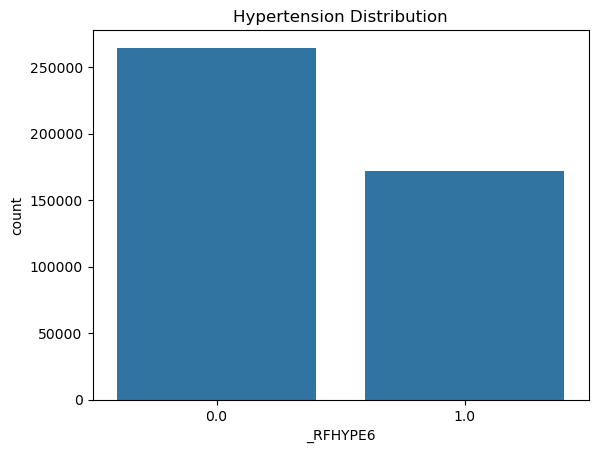

In [15]:
sns.countplot(x='_RFHYPE6', data=df)
plt.title("Hypertension Distribution")
plt.show()

Note - We can see from the countplot and the value counts that around 39% of the sample population have been told that they have high blood pressure

In [17]:
print(df[['_BMI5', '_FRUTSU1', '_VEGESU1', 'GRENDA1_','FRNCHDA_']].describe())

               _BMI5       _FRUTSU1       _VEGESU1       GRENDA1_  \
count  436781.000000  436781.000000  436781.000000  436781.000000   
mean     2840.714248     128.800227     186.396991      51.087815   
std       608.871765     108.546506     126.271100      51.981462   
min      1200.000000       0.000000       0.000000       0.000000   
25%      2441.000000      58.000000     123.000000      14.000000   
50%      2744.000000     100.000000     164.000000      43.000000   
75%      3109.000000     200.000000     215.000000      71.000000   
max      6994.000000    1000.000000    1500.000000     500.000000   

            FRNCHDA_  
count  436781.000000  
mean       20.128073  
std        26.301559  
min         0.000000  
25%         7.000000  
50%        14.000000  
75%        29.000000  
max       300.000000  


In [19]:
#BMI5, FRUTSU1, VEGESU1,GRENDA1, FRNCHDA_ have implied 2 decimal places and so we need to rescale them by 100 before plotting 
df['_BMI5'] = df['_BMI5'] / 100
df['_FRUTSU1'] = df['_FRUTSU1'] / 100
df['_VEGESU1'] = df['_VEGESU1'] / 100
df['GRENDA1_'] = df['GRENDA1_'] / 100
df['FRNCHDA_'] = df['FRNCHDA_'] / 100

# Check
print(df[['_BMI5', '_FRUTSU1', '_VEGESU1', 'GRENDA1_','FRNCHDA_']].describe())

               _BMI5       _FRUTSU1       _VEGESU1       GRENDA1_  \
count  436781.000000  436781.000000  436781.000000  436781.000000   
mean       28.407142       1.288002       1.863970       0.510878   
std         6.088718       1.085465       1.262711       0.519815   
min        12.000000       0.000000       0.000000       0.000000   
25%        24.410000       0.580000       1.230000       0.140000   
50%        27.440000       1.000000       1.640000       0.430000   
75%        31.090000       2.000000       2.150000       0.710000   
max        69.940000      10.000000      15.000000       5.000000   

            FRNCHDA_  
count  436781.000000  
mean        0.201281  
std         0.263016  
min         0.000000  
25%         0.070000  
50%         0.140000  
75%         0.290000  
max         3.000000  


In [21]:
#We now look to analyze the distributions of all of the independent variables 

#1. First, we look at all the continuous variables 
cont_vars = ['_AGE80', '_BMI5', '_FRUTSU1', '_VEGESU1','GRENDA1_','FRNCHDA_']

df[cont_vars].describe()

,_AGE80,_BMI5,_FRUTSU1,_VEGESU1,GRENDA1_,FRNCHDA_
count,436781.000000,436781.000000,436781.000000,436781.000000,436781.000000,436781.000000
mean,54.688366,28.407142,1.288002,1.863970,0.510878,0.201281
std,17.571461,6.088718,1.085465,1.262711,0.519815,0.263016
min,18.000000,12.000000,0.000000,0.000000,0.000000,0.000000
25%,41.000000,24.410000,0.580000,1.230000,0.140000,0.070000
50%,57.000000,27.440000,1.000000,1.640000,0.430000,0.140000
75%,69.000000,31.090000,2.000000,2.150000,0.710000,0.290000
max,80.000000,69.940000,10.000000,15.000000,5.000000,3.000000


Observations
1. Mean age is 55 years old with an average BMI of 28.4. 
2. There is approximately 1.7 equivalent fruit consumption units per day, 2.6 equivalent vegetable consumption units per day, 0.8 equivalent green vegetable consumption, 0.2 equivalent consumption of french fries

Note: As per 2026 Food Dietary Guidelines from USDA, It is recommended to have  3 servings per day for Vegetables and 2 servings per day of Fruits. 
While our variable is not necessarily measured in servings, the average consumption is close enough to the guidelines. 

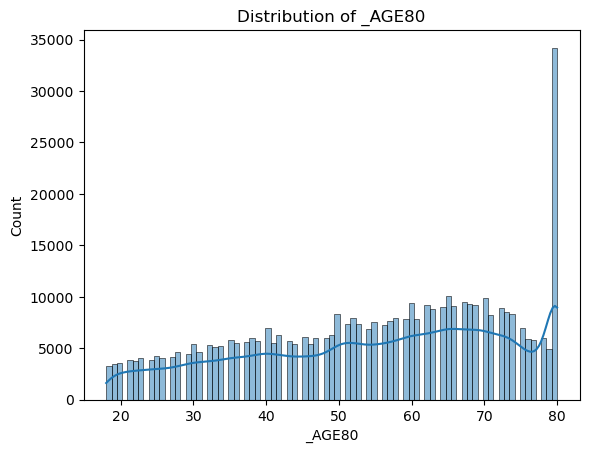

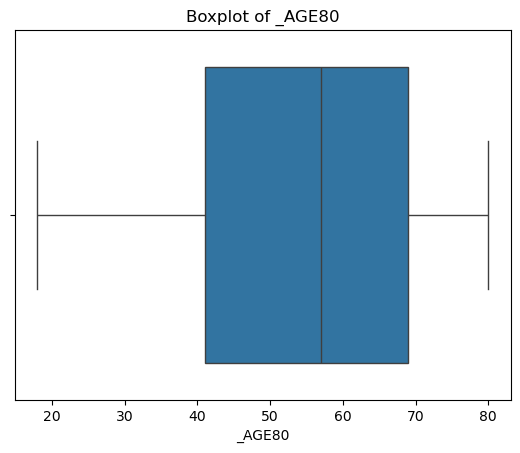

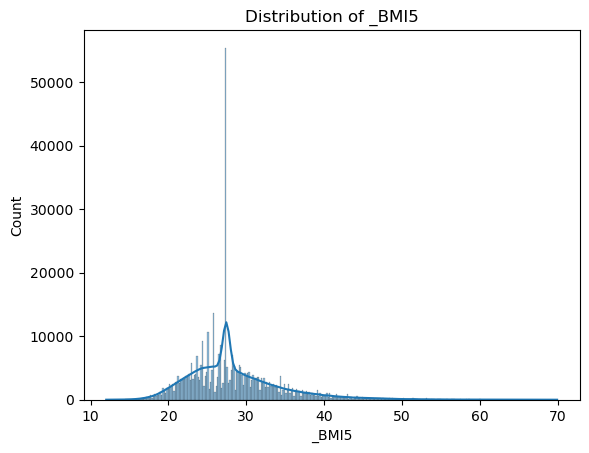

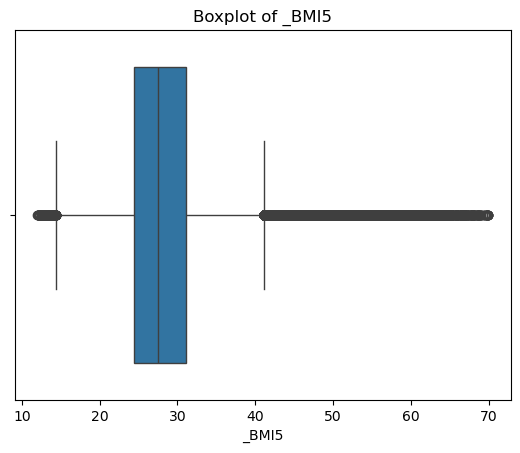

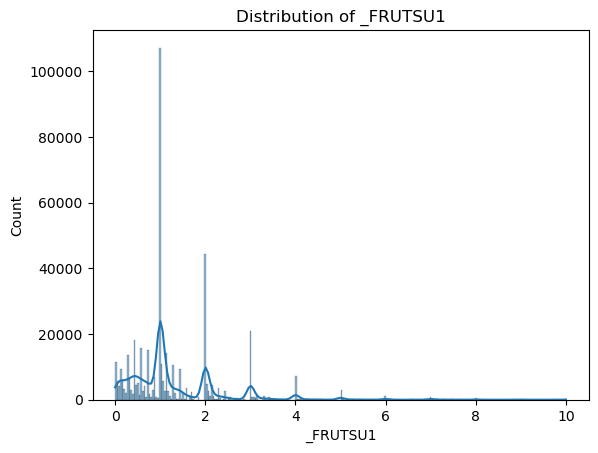

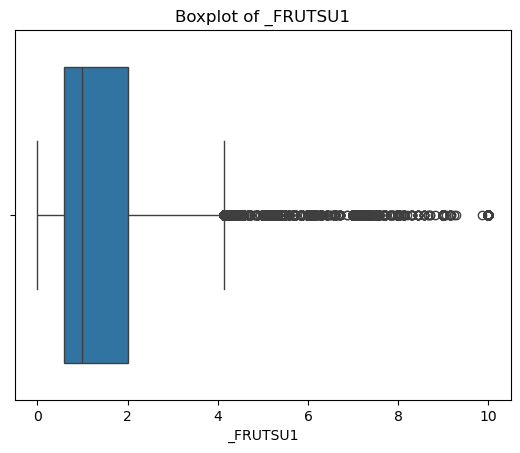

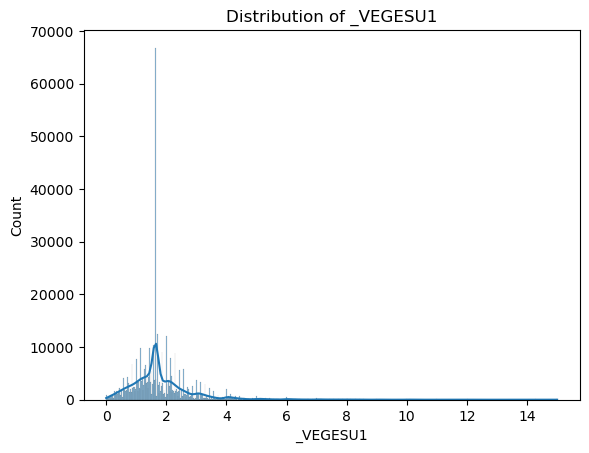

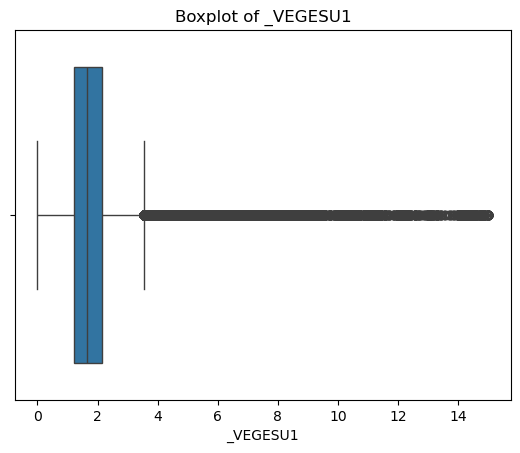

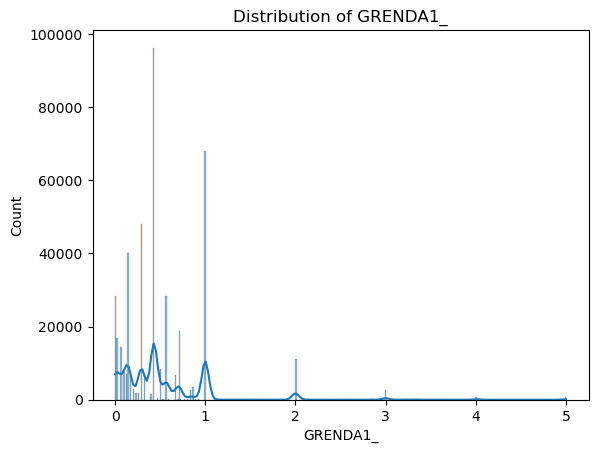

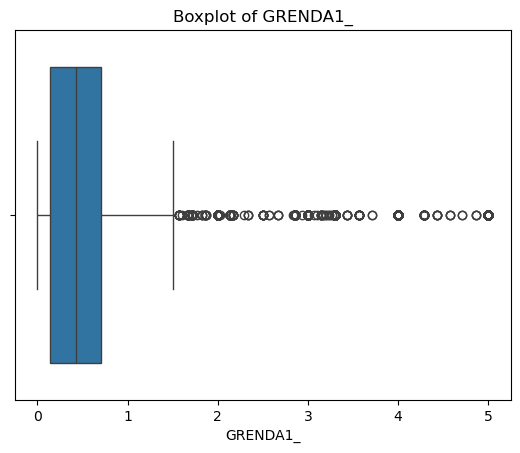

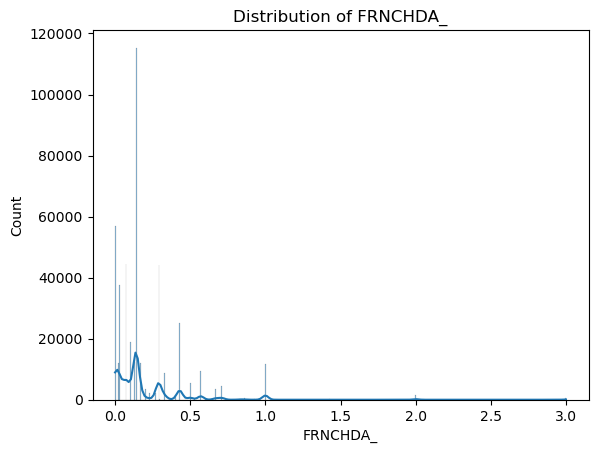

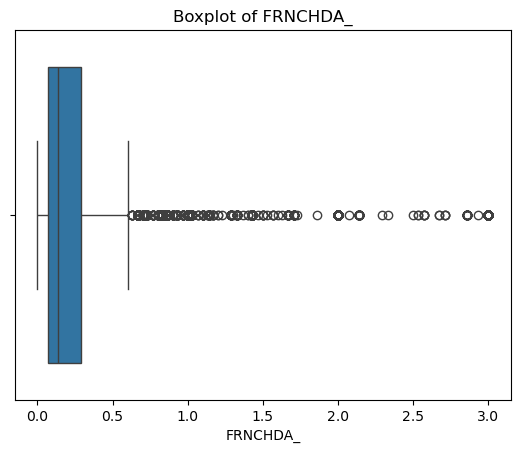

In [23]:
for col in cont_vars:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Looking at the distributions of these variables, we can see that despite data cleaning, there are a few outliers in the dietary variables (but within a reasonable threshold). 

For the BMI variable, I first looked at the original data and saw that there were a lot of outliers that were well above the range for biological plausibility (i.e. BMI of 70 or greater). These were dealt with in the data wrangling stage.

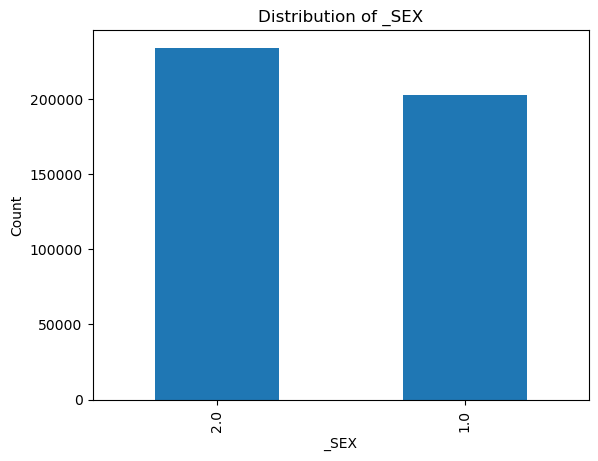

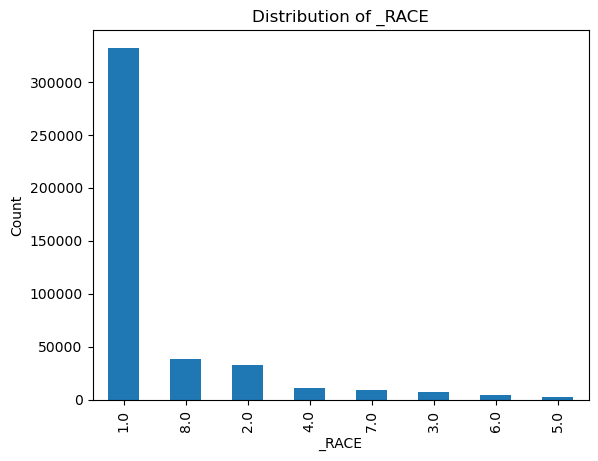

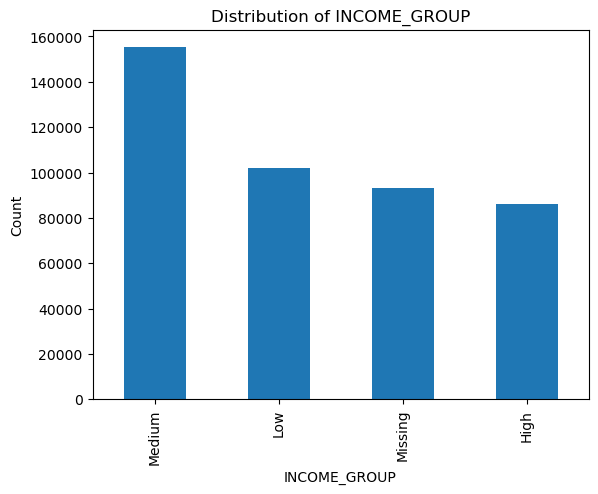

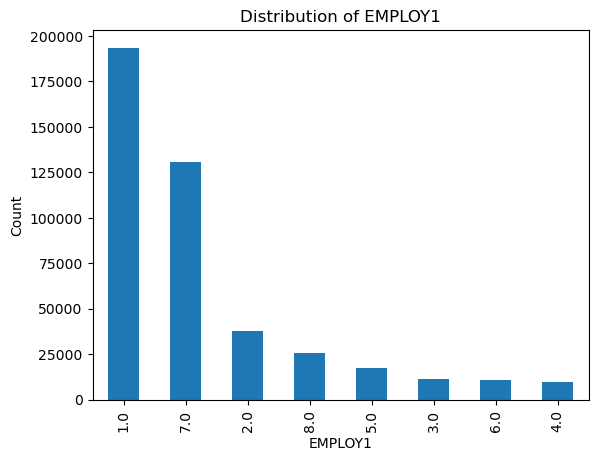

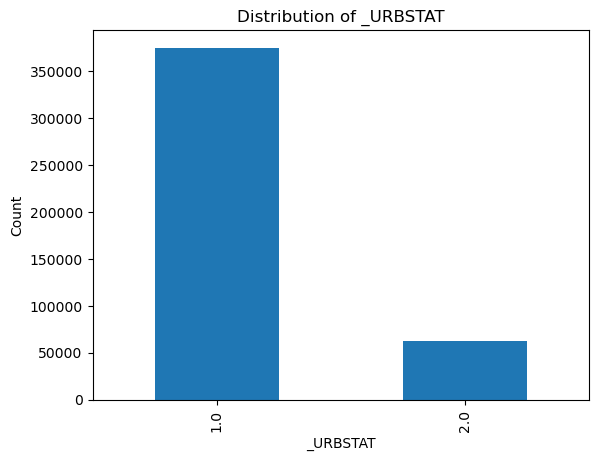

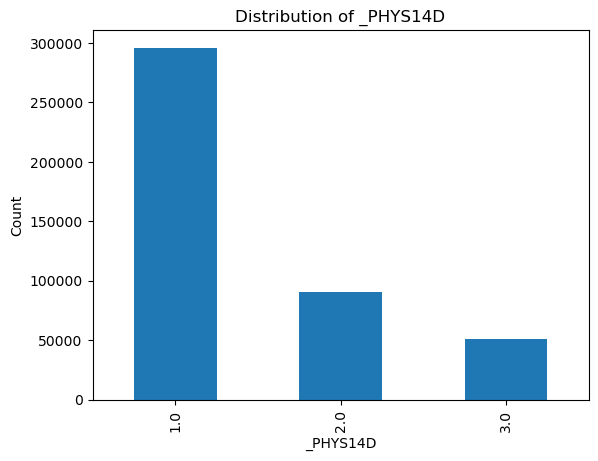

In [24]:
#Now, we will look at all the categorical demographic variables 
cat_vars = ['_SEX', '_RACE', 'INCOME_GROUP', 'EMPLOY1', '_URBSTAT', '_PHYS14D']

for col in cat_vars:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {col}")
    plt.ylabel("Count")
    plt.show()

Observations:
1. More men than women in the sample. 
2. Predominantly white only, non-hispanic. Small % are Hispanic, African-Americans, Asians, and other races or multi-racial identities. Lowest representation of native Hawaiian or other Pacific Islanders.
3. A large % of the sample are from the medium income group (reporting earning between 35-100k), followed by the low income group (<35k). High number of missing income (as identified in the data wrangling stage).
4. Highest representation of employment for wages, followed by retired. This corroborates with our mean sample age being around 58 years old.
5. Sample is predominantly from urban counties.
6. Sample largely reports good physical health. 

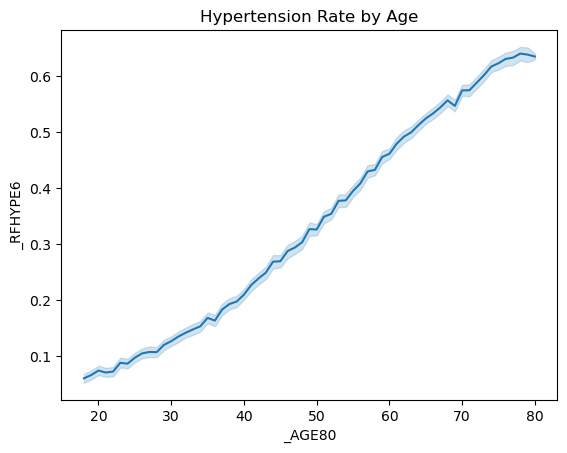

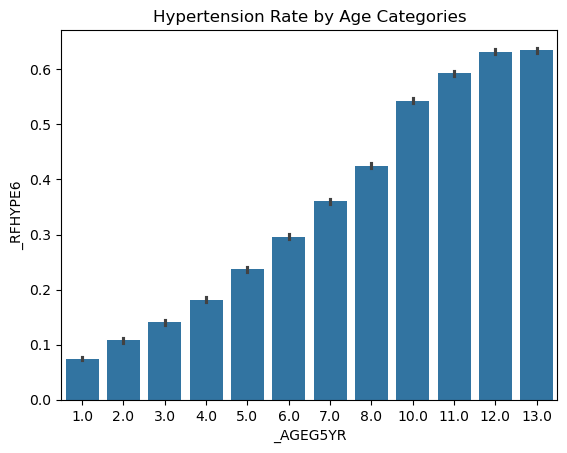

In [27]:
#I will now analyze the relationsip with hypertension and demographic variables (Age, Sex, Race) 

#Age (Continuous) Vs Hypertension 
sns.lineplot(x='_AGE80', y='_RFHYPE6', data=df)
plt.title("Hypertension Rate by Age")
plt.show()

#Age (Categories) Vs Hypertension
sns.barplot(x='_AGEG5YR', y='_RFHYPE6', data=df)
plt.title("Hypertension Rate by Age Categories")
plt.show()

Observation - We can see in the line plots that the prevalence of hyptertension does increase as age increases. From the boxplot, we can see that while hypertension increases, the rate tends to taper out from Ages 75+ onwards. 

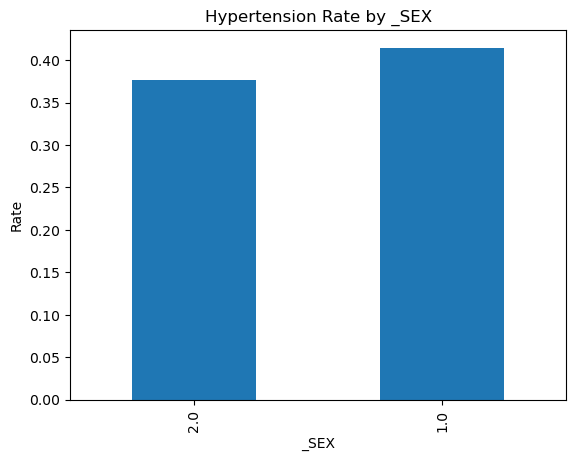

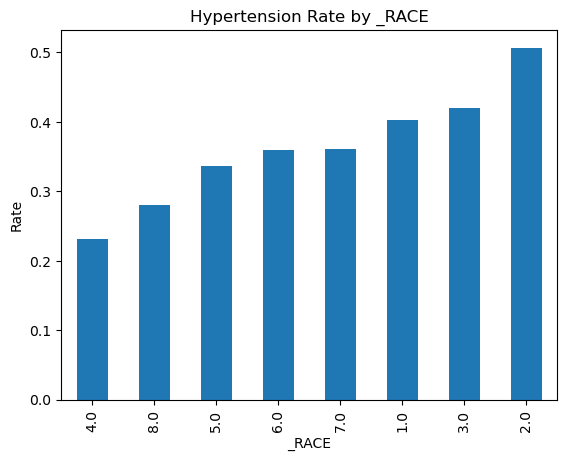

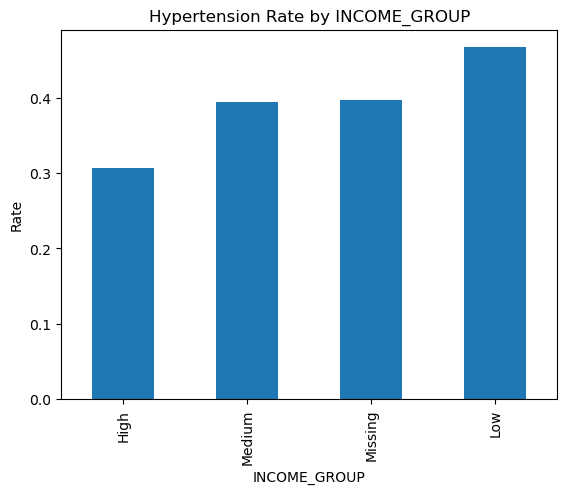

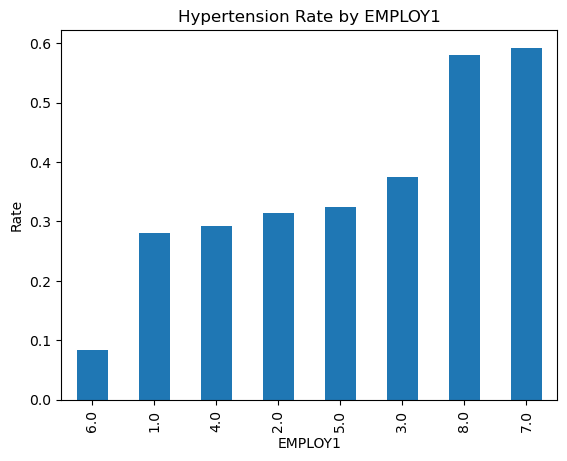

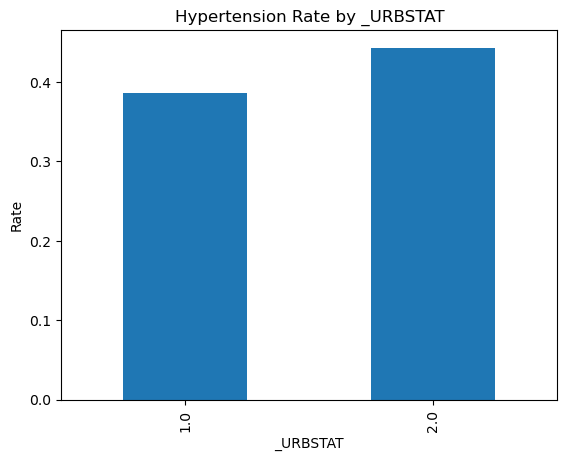

In [30]:
#Hypertension vs Categorical demographic variables (Sex, Race, income group, employment status, Urban/rural)

demo_vars = ['_SEX', '_RACE', 'INCOME_GROUP', 'EMPLOY1', '_URBSTAT']

for col in demo_vars:
    plt.figure()
    temp = df.groupby(col)['_RFHYPE6'].mean().sort_values()
    temp.plot(kind='bar')
    plt.title(f"Hypertension Rate by {col}")
    plt.ylabel("Rate")
    plt.show()

Observations:
1. Both men and women have similar rates of hypertension, with men (40%) being slightly higher than women (37%).
2. Hispanics seem to have the highest hypertension rate (50%), followed by African-American (40%), and then White Caucasians (~ 40%). 
3. The lowest income class have the highest prevalence of hypertension (~50%), followed by the missing income group, and then the medium group (both at around 40%). 30% of those in the high income class have hypertension.
4. Almost close to 60% of those retired and those unable to work have hypertension. Around 37% of those unemployed for a year or more have hypertension, around 30% homemakers and those self-employed report having hypertension. Less than 30% of employed adults report hypertension and the lowest cateory (less than 10%) are students.
5. More than 40% of the population living in rural counties report hypertension, as compared to urban county population. 

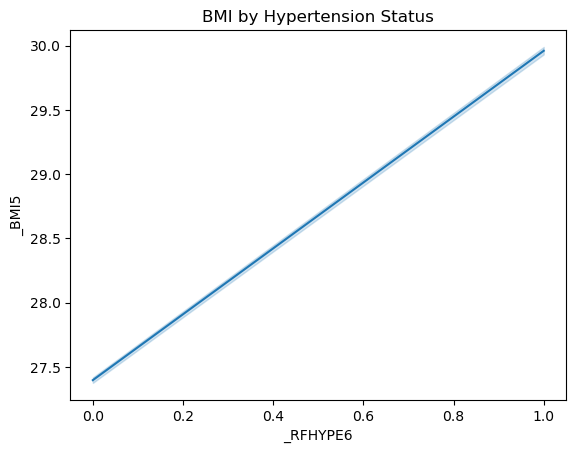

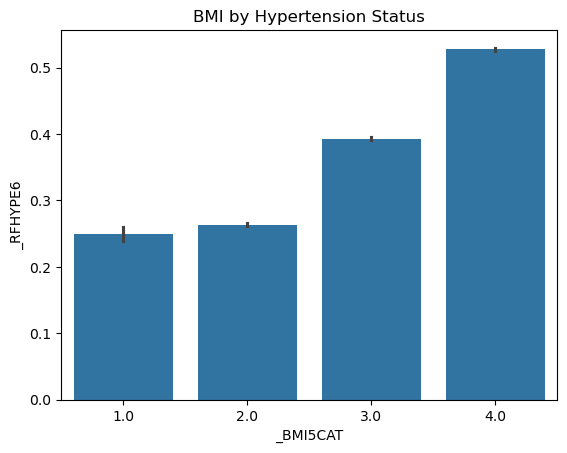

In [40]:
#Hypertension vs BMI (Continuous)

sns.lineplot(x='_RFHYPE6', y='_BMI5', data=df)
plt.title("BMI by Hypertension Status")
plt.show()

#Hypertension vs BMI (Categories)
sns.barplot(x='_BMI5CAT', y='_RFHYPE6', data=df)
plt.title("BMI by Hypertension Status")
plt.show()

Observations:
1. From the lineplot, it's clear that as BMI increases, prevalence of hypertension increases.
2. This is also supported by the bar graph looking at the BMI categories. We can see that there is a significantly large jump in hypertension in going from the normal BMI to the overweight BMI category. 

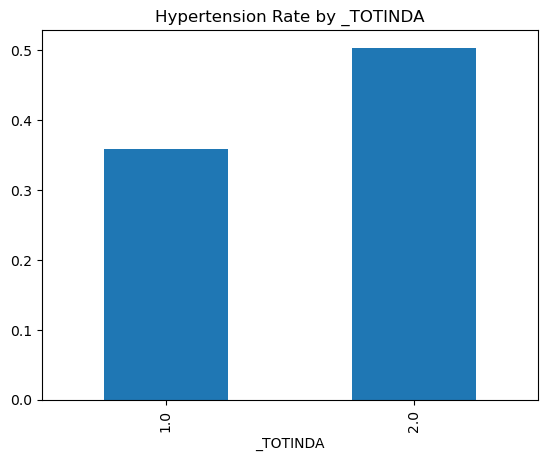

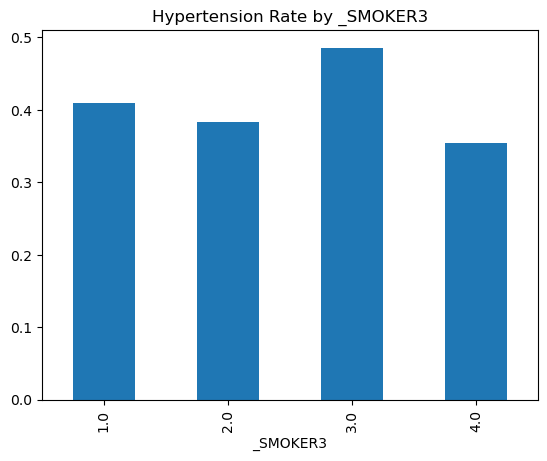

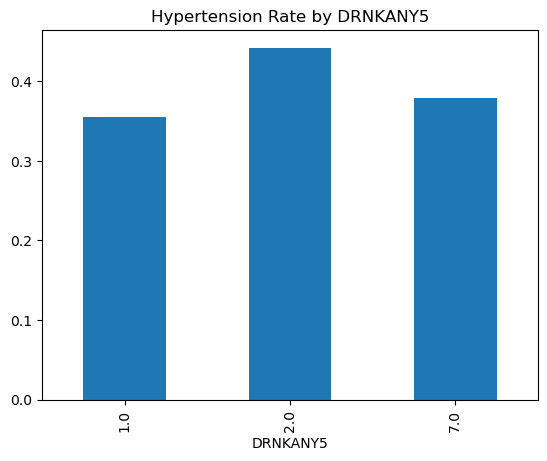

In [43]:
#Hypertension vs. Lifestyle indicators (Physical activity, smoking, drinking alcohol)

lifestyle_vars = ['_TOTINDA', '_SMOKER3', 'DRNKANY5']

for col in lifestyle_vars:
    plt.figure()
    temp = df.groupby(col)['_RFHYPE6'].mean()
    temp.plot(kind='bar')
    plt.title(f"Hypertension Rate by {col}")
    plt.show()

Observations:
1. The sample that never did any physical activity in the last 30 days had a higher prevalence than those that did.
2. Former smokers have the highest hypertension prevalence (~50%), followed by current frequent smokers (40%) and current less frequent smokers (<40%). Those that never smoked were at around 35%.
3. People that didn't drink any alcohol beverages in the last 30 days reported >40% hypertension, follwed by don't know/not sure category. 35% of those that reported consuming alcoholic beverages have hypertension. This does make me wonder if these were reported truthfully.


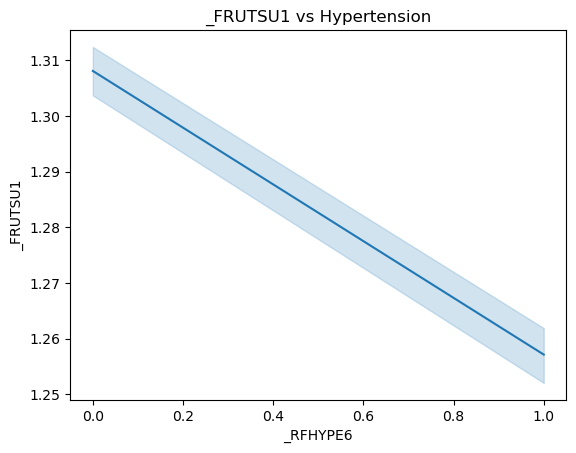

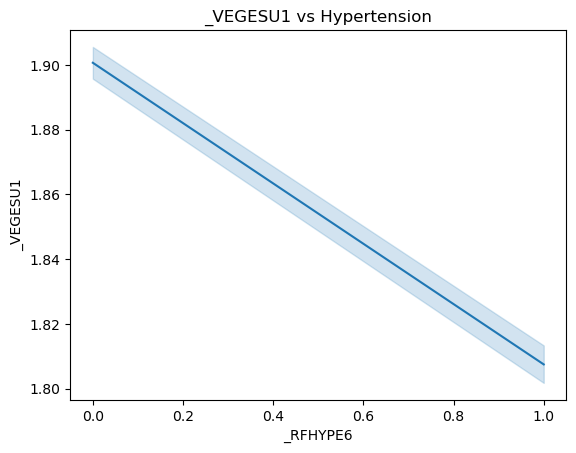

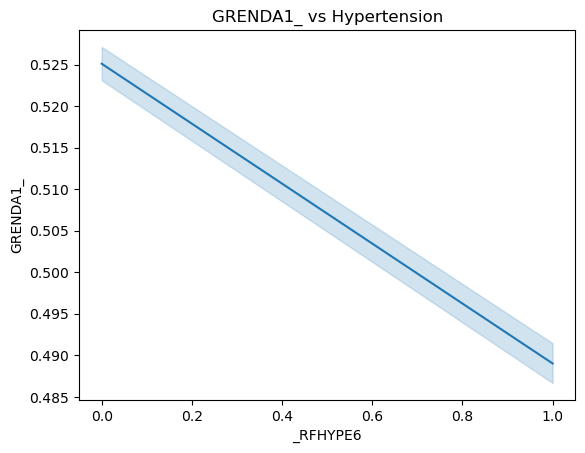

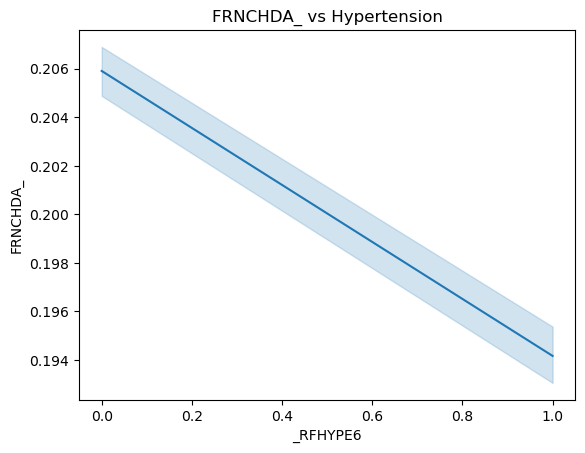

In [52]:
#Hypertension vs. nutrition variables 

nutrition_vars = ['_FRUTSU1', '_VEGESU1', 'GRENDA1_','FRNCHDA_']

for col in nutrition_vars:
    sns.lineplot(x='_RFHYPE6', y=col, data=df)
    plt.title(f"{col} vs Hypertension")
    plt.show()

Observations:
1. As predicted, for all dietary/nutrition variables, the less consumption is related to a higher hypertension rate. 

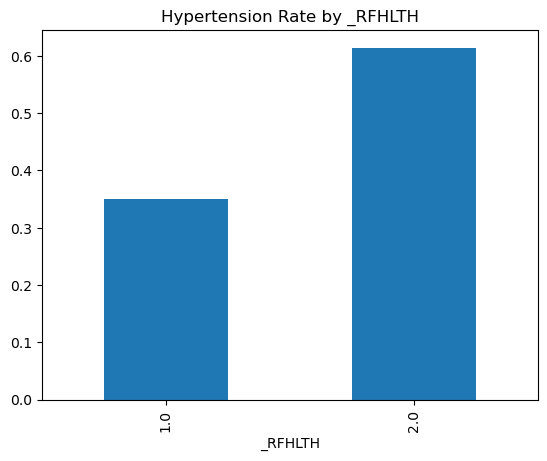

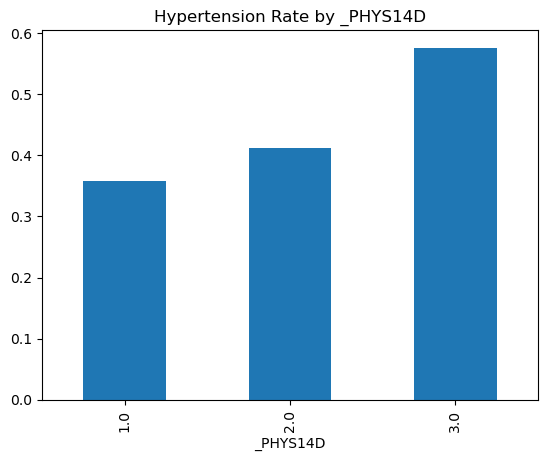

In [55]:
#Hypertension vs Health Status variables 

health_vars = ['_RFHLTH', '_PHYS14D']

for col in health_vars:
    plt.figure()
    temp = df.groupby(col)['_RFHYPE6'].mean()
    temp.plot(kind='bar')
    plt.title(f"Hypertension Rate by {col}")
    plt.show()

Observations: 
1. Population that reported fair or poor health have a higher hypertension rate than those that reported good or better health 
2. Population that reported more days where physical health was not good is related to higher hypertension prevalence. 

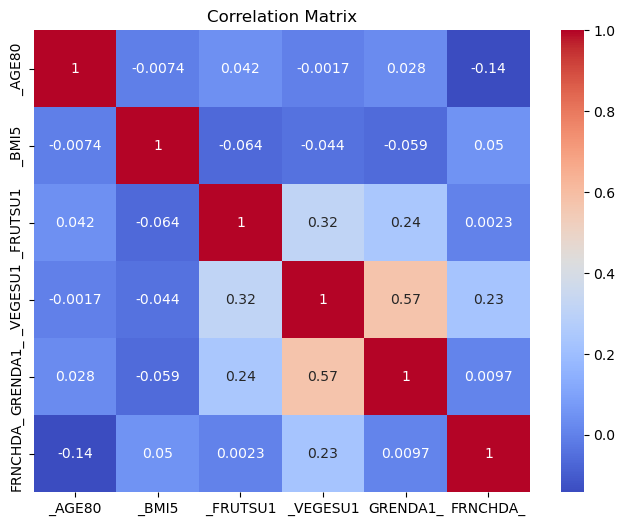

In [58]:
#Correlation between the continuous variables
numeric_vars = ['_AGE80', '_BMI5', '_FRUTSU1', '_VEGESU1', 'GRENDA1_','FRNCHDA_']

corr = df[numeric_vars].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

We don't see a lot of strong positive or negative correlation between the continous variables, with the exception of Vegetable and Dark Green vegetable consumption. It is not very strong correlation but it might make sense to drop one to avoid redudancy. I would drop the dark green vegetables indicator. 

C:\Users\Abhi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


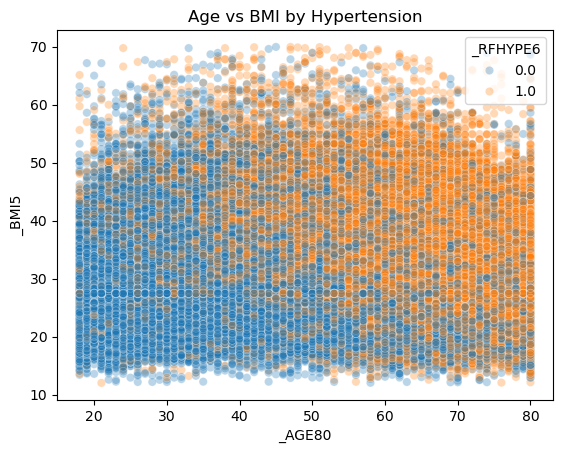

In [61]:
#Looking at the interaction between Age and BMI with Hypertension

sns.scatterplot(x='_AGE80', y='_BMI5', hue='_RFHYPE6', data=df, alpha=0.3)
plt.title("Age vs BMI by Hypertension")
plt.show()

Observation - We can see that as age goes up, the prevalance of hypertension increases and as you get older, your BMI might not matter as much. This is because we can stil observe hypertension prevalence among older adults, even with a lower BMI range.

In [63]:
#Looking at Income and Race 
pd.crosstab(df['INCOME_GROUP'], df['_RACE'], normalize='index')

_RACE,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0
INCOME_GROUP,,,,,,,,
High,0.830921,0.047163,0.007747,0.037132,0.003630,0.007468,0.019076,0.046862
Low,0.655443,0.106202,0.028718,0.019341,0.005620,0.010269,0.025952,0.148455
Medium,0.792896,0.068481,0.014446,0.023044,0.004644,0.007374,0.020416,0.068700
Missing,0.756360,0.076606,0.014970,0.028064,0.004050,0.011498,0.018474,0.089979


Observation - Causian group have the highest % across the income group categories, reporting the highest missing income as well. There is no discernable pattern among the other race groups

In [73]:
# Income
print(df.groupby('INCOME_GROUP')['_RFHYPE6'].mean())

# BMI categories 
print(df.groupby('_BMI5CAT')['_RFHYPE6'].mean())

# Physical activity
print(df.groupby('_TOTINDA')['_RFHYPE6'].mean())

INCOME_GROUP
High       0.306383
Low        0.466677
Medium     0.393811
Missing    0.396316
Name: _RFHYPE6, dtype: float64
_BMI5CAT
1.0    0.249121
2.0    0.263632
3.0    0.393139
4.0    0.527195
Name: _RFHYPE6, dtype: float64
_TOTINDA
1.0    0.358678
2.0    0.503988
Name: _RFHYPE6, dtype: float64


Observations - 
1. 47% from the low income group report hypertension. Around 39% from the medium and missing income group report hypertension. 31% from the higher income group report hypertension. While the number is lower than the other groups, 31% is still a significantly high prevalance.
2. As BMI increases, hypertension prevalance also increases.
3. People who report doing no physical activity or excercise over the last 30 days have a significantly higher prevalance of hypertension. 

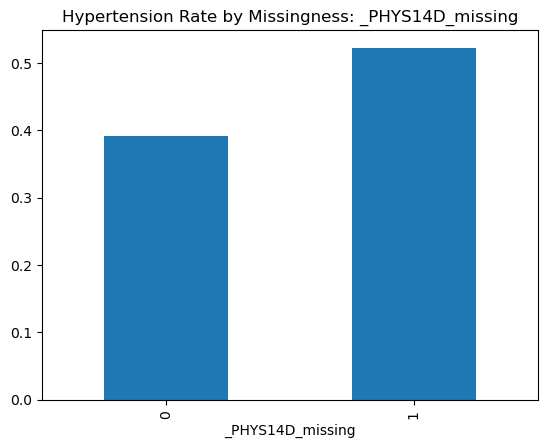

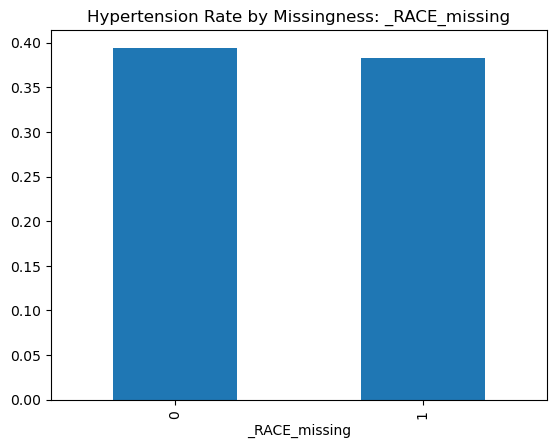

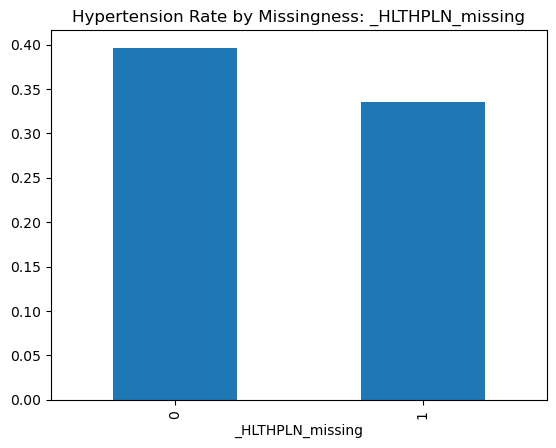

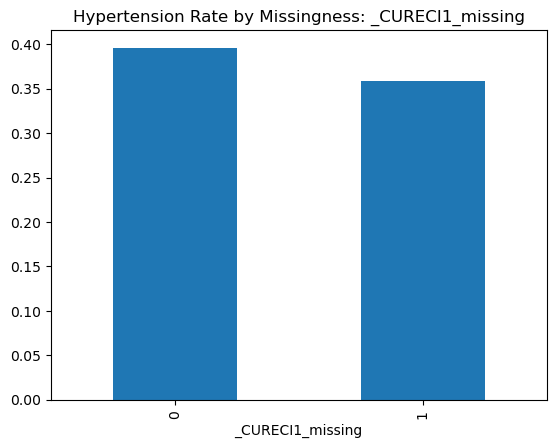

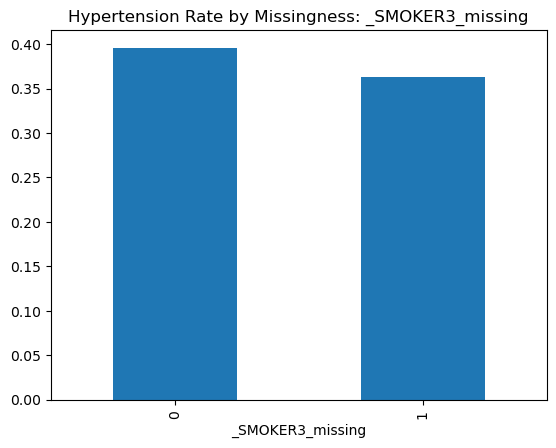

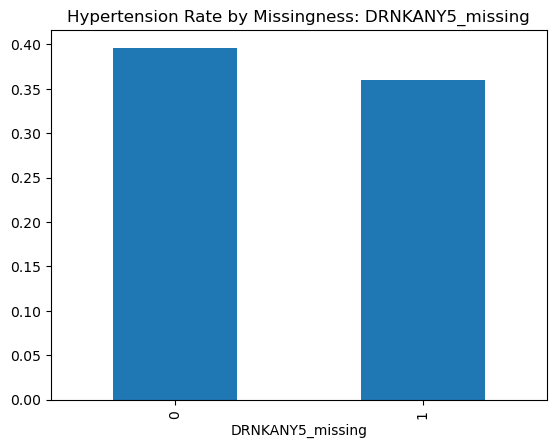

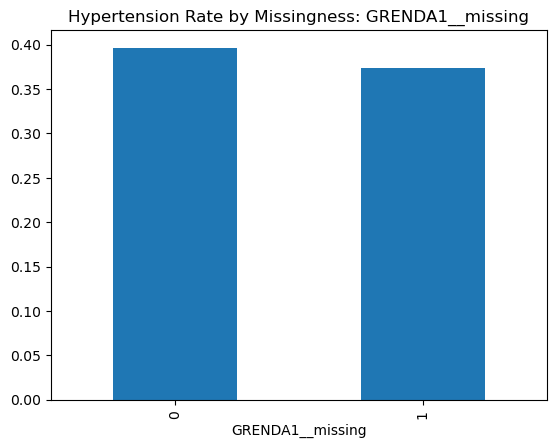

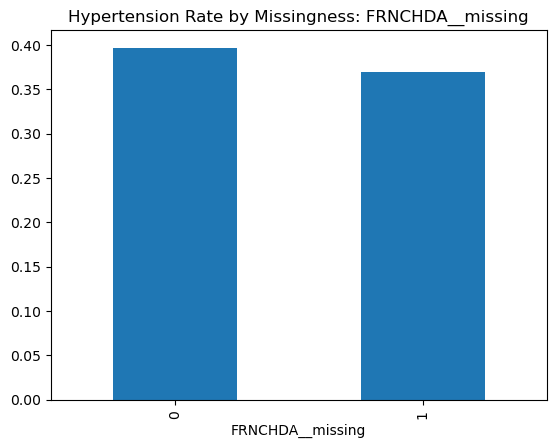

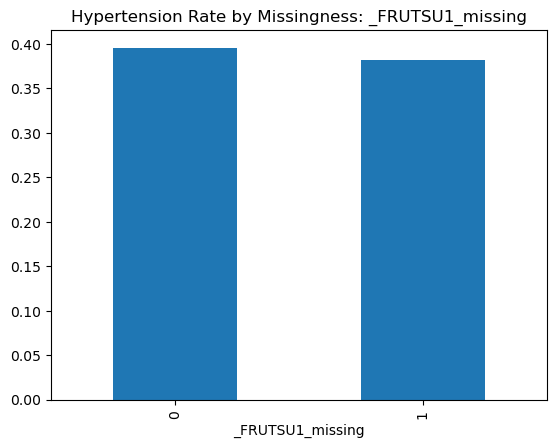

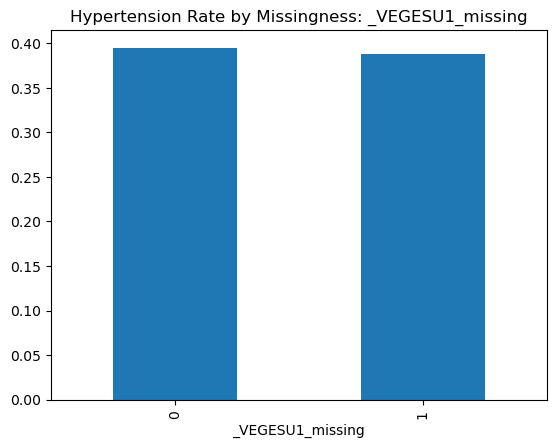

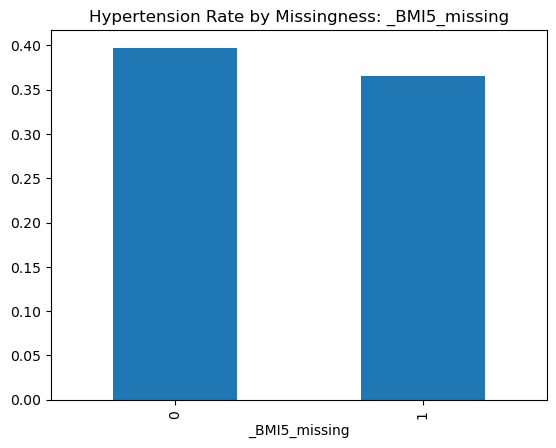

In [77]:
#Looking at the indicators that have missing observations and their relationship to Hypertension 
missing_vars = [col for col in df.columns if '_missing' in col]

for col in missing_vars:
    plt.figure()
    temp = df.groupby(col)['_RFHYPE6'].mean()
    temp.plot(kind='bar')
    plt.title(f"Hypertension Rate by Missingness: {col}")
    plt.show()

With the exception of the health status variable (_PHYS14D) where the missing indicator (missing=1) has a higher hypertension rate, I do not observe any significant relationship with missing observations and hypertension prevalance. 

Final Notes:
1. I observe strong relationships with the predictor variables and our target variables (Hypertension). I would keep all of them for the training of the model. 
2. I am going to drop the dark green vegetable consumption (as it seems moderately correlated with vegetable consumption indicator) and would largely be redundant.
3. I am also going to drop alcohol consumption indicator (DRNKANY5) because as observed from the graph, I have some doubts over the truthfullness of the responses. 